In [1]:
import pysr as PySRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
import numpy as np
import matplotlib.pyplot as plt

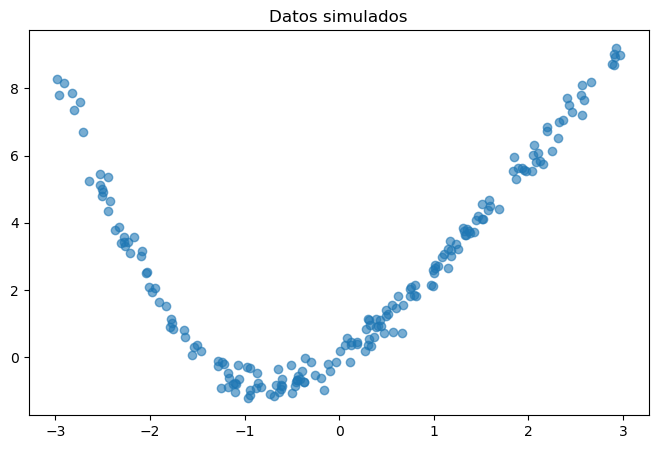

In [3]:
np.random.seed(123)
n = 200
x = np.random.uniform(-3,3,n)
epsilon = np.random.normal(loc =0, scale = 0.3, size = n)
y= x**2 + 2*np.sin(x) + epsilon

plt.figure(figsize = (8,5))
plt.scatter(x,y, alpha = 0.6)
plt.title("Datos simulados")
plt.show()

In [4]:
from pysr import PySRRegressor

X = x.reshape(-1, 1)

model = PySRRegressor(
    niterations=20,
    binary_operators=[
        "+",
        "-",
        "*"
    ],
    unary_operators=[
        "sin"
    ],
    verbosity=1
)

model.fit(X, y)

/home/gdiek/anaconda3/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.351e+00  0.000e+00  y = 2.5616
3           2.145e+00  6.796e-01  y = x₀ * x₀
5           6.728e-01  5.797e-01  y = (x₀ - -0.76096) * x₀
6           5.930e-01  1.262e-01  y = sin(x₀) + (x₀ * x₀)
8           8.288e-02  9.839e-01  y = (sin(x₀) * 1.9896) + (x₀ * x₀)
10          8.156e-02  7.986e-03  y = ((x₀ * x₀) + -0.036266) + (sin(x₀) * 1.9915)
12          8.122e-02  2.095e-03  y = (x₀ * x₀) - ((sin(0.013798 - x₀) * 1.9924) - -0.031741...
                                      )
14          8.119e-02  2.288e-04  y = (x₀ * (x₀ - -0.0071369)) - ((0.015909 - sin(x₀ - 0.013...
                                      965)) * 1.9791)
16          8.065e-02  3.291e-03  y = sin(x₀) + ((x₀ * x₀) + sin(x₀ - (sin(x₀ * x₀) * 0.1334...
                                      3)))
18          7.965e-02  6.251e-03  y = (sin(x₀ - (sin(x₀ * (x₀ * 1.8909))

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                           2.561635   
	1         0.679629                                            x0 * x0   
	2         0.579735                              (x0 - -0.760963) * x0   
	3         0.126188                                sin(x0) + (x0 * x0)   
	4   >>>>  0.983948                   (sin(x0) * 1.989588) + (x0 * x0)   
	5         0.007986  ((x0 * x0) + -0.036265932) + (sin(x0) * 1.991523)   
	6         0.002095  (x0 * x0) - ((sin(0.013797574 - x0) * 1.992365...   
	7         0.000229  (x0 * (x0 - -0.007136869)) - ((0.015909294 - s...   
	8         0.003291  sin(x0) + ((x0 * x0) + sin(x0 - (sin(x0 * x0) ...   
	9         0.006251  (sin(x0 - (sin(x0 * (x0 * 1.890914)) * 0.11466...   
	10        0.003536  (sin(x0 + sin(sin(x0 * (x0 * -1.8728478)) * 0....   
	11        0.026821  (sin(x0) + sin((sin((x0 + (x0 - -0.47965094)) ...   
	12        0.000134  (sin((sin((x0 + (x0 + 0.47788736)) * x0) * -0....   
	13        0.000955  (sin(x0 + (sin(x0 * x0) * -0.05346333)) + sin(...   
	
	        loss  complexity  
	0   8.351337           1  
	1   2.145050           3  
	2   0.672800           5  
	3   0.593039           6  
	4   0.082878           8  
	5   0.081564          10  
	6   0.081223          12  
	7   0.081186          14  
	8   0.080653          16  
	9   0.079651          18  
	10  0.079370          19  
	11  0.077270          20  
	12  0.077228          24  
	13  0.077007          27  
]

  - outputs/20260921_121029_K2fuqb/hall_of_fame.csv


In [5]:
model.equations_

,complexity,loss,equation,score,sympy_format,lambda_format
0,1,8.351337,2.561635,0.000000,2.56163500000000,PySRFunction(X=>2.56163500000000)
1,3,2.145050,x0 * x0,0.679629,x0*x0,PySRFunction(X=>x0*x0)
2,5,0.672800,(x0 - -0.760963) * x0,0.579735,x0*(x0 - 1*(-0.760963)),PySRFunction(X=>x0*(x0 - 1*(-0.760963)))
3,6,0.593039,sin(x0) + (x0 * x0),0.126188,x0*x0 + sin(x0),PySRFunction(X=>x0*x0 + sin(x0))
4,8,0.082878,(sin(x0) * 1.989588) + (x0 * x0),0.983948,x0*x0 + sin(x0)*1.989588,PySRFunction(X=>x0*x0 + sin(x0)*1.989588)
5,10,0.081564,((x0 * x0) + -0.036265932) + (sin(x0) * 1.991523),0.007986,x0*x0 + sin(x0)*1.991523 - 0.036265932,PySRFunction(X=>x0*x0 + sin(x0)*1.991523 - 0.0...
6,12,0.081223,(x0 * x0) - ((sin(0.013797574 - x0) * 1.992365...,0.002095,x0*x0 - (sin(0.013797574 - x0)*1.9923655 - 1*(...,PySRFunction(X=>x0*x0 - (sin(0.013797574 - x0)...
7,14,0.081186,(x0 * (x0 - -0.007136869)) - ((0.015909294 - s...,0.000229,x0*(x0 - 1*(-0.007136869)) - 1.9790826*(0.0159...,PySRFunction(X=>x0*(x0 - 1*(-0.007136869)) - 1...
8,16,0.080653,sin(x0) + ((x0 * x0) + sin(x0 - (sin(x0 * x0) ...,0.003291,x0*x0 + sin(x0) + sin(x0 - 0.13342816*sin(x0*x0)),PySRFunction(X=>x0*x0 + sin(x0) + sin(x0 - 0.1...
9,18,0.079651,(sin(x0 - (sin(x0 * (x0 * 1.890914)) * 0.11466...,0.006251,x0*x0 + sin(x0) + sin(x0 - 0.11466471*sin(x0*x...,PySRFunction(X=>x0*x0 + sin(x0) + sin(x0 - 0.1...


In [6]:
model.sympy()

x0*x0 + sin(x0)*1.989588

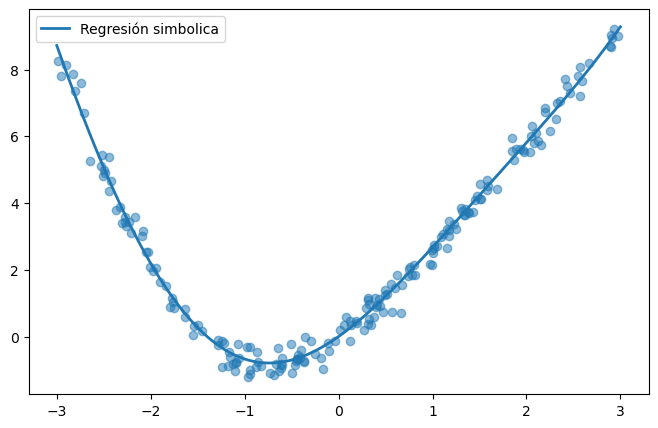

In [7]:
X_grid = np.linspace(-3,3,500)
X_grid = X_grid.reshape(-1,1)

y_pred = model.predict(X_grid)
plt.figure(figsize = (8,5))
plt.scatter(x, y, alpha = 0.5)
plt.plot(X_grid,y_pred, linewidth = 2, label = "Regresión simbolica")
plt.legend()
plt.show()

# Ejercicios

## 8.11.1 Ejercicio 1: Datos simulados
Genera ahora un nuevo conjunto de datos utilizando


Genera 
 observaciones con 
.
Ajusta un modelo de regresión simbólica utilizando solamente

Observa las ecuaciones encontradas.
    
Compara la expresión seleccionada con

Grafica los datos y la función encontrada.
    
¿Logra PySR recuperar aproximadamente la estructura de la función original? 

Si

¿Qué ocurre con los coeficientes debido a la presencia de ruido?

Son aproximaciones de la las originales

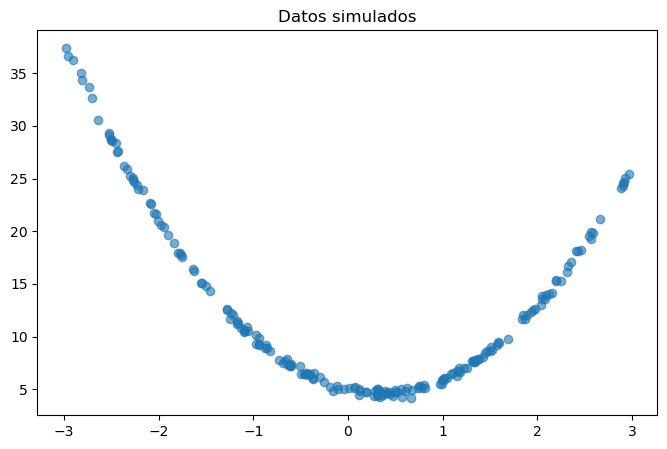

/home/gdiek/anaconda3/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.924e+01  0.000e+00  y = 12.558
3           6.084e+01  6.466e-02  y = 12.577 - x₀
5           2.170e+01  5.155e-01  y = (x₀ * x₀) * 4.0009
7           1.022e+01  3.764e-01  y = ((x₀ * 3.047) * x₀) + 4.8109
9           5.638e-02  2.600e+00  y = ((x₀ * 3.0067) * (x₀ + -0.66543)) + 4.9526
11          5.638e-02  2.980e-08  y = (((x₀ * 3.0067) * (x₀ + -0.66543)) + 6.7851) - 1.8326
13          5.638e-02  1.192e-07  y = ((x₀ * 3.0067) * (x₀ - 0.00024118)) + (4.9526 - (x₀ + ...
                                      x₀))
15          5.638e-02  6.974e-06  y = ((x₀ * (x₀ * (3.0067 - (x₀ * -0.00016467)))) + 4.9525)...
                                       - (x₀ + x₀)
17          5.635e-02  2.943e-04  y = (((x₀ * (3.0066 - (x₀ * -0.0015231))) * x₀) + 4.953) -...
                                       (x₀ + (x₀ * 1.0084))
19          5.635e-02  

[ Info: Final population:
[ Info: Results saved to:


x0*3.0066898*(x0 - 0.665428) + 4.9525967

  - outputs/20260921_122134_WaIIUZ/hall_of_fame.csv


In [14]:
np.random.seed(123)
n = 200
x = np.random.uniform(-3,3,n)
epsilon = np.random.normal(loc =0, scale = (0.5)**2, size = n)
y= 3*x**2 - 2*x +5 + epsilon

plt.figure(figsize = (8,5))
plt.scatter(x,y, alpha = 0.6)
plt.title("Datos simulados")
plt.show()

from pysr import PySRRegressor

X = x.reshape(-1, 1)

model = PySRRegressor(
    niterations=20,
    binary_operators=[
        "+",
        "-",
        "*"
    ],
    verbosity=1
)

model.fit(X, y)

model.sympy()

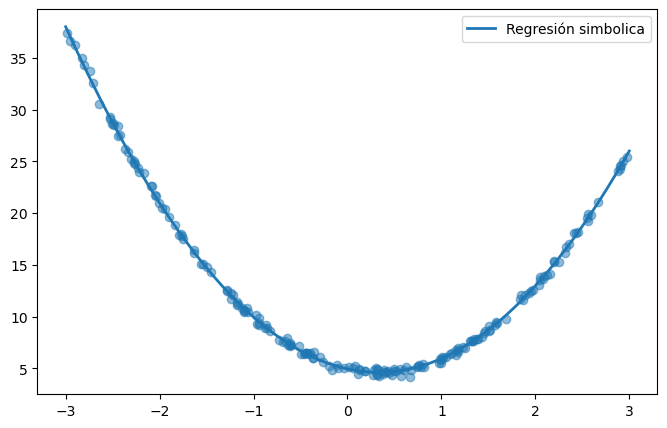

In [15]:
X_grid = np.linspace(-3,3,500)
X_grid = X_grid.reshape(-1,1)

y_pred = model.predict(X_grid)
plt.figure(figsize = (8,5))
plt.scatter(x, y, alpha = 0.5)
plt.plot(X_grid,y_pred, linewidth = 2, label = "Regresión simbolica")
plt.legend()
plt.show()

## Ejercicio 2

En los ejemplos anteriores trabajamos con el conjunto de datos Wage para estudiar la relación entre la edad (age) y el salario (wage) utilizando diferentes técnicas de regresión no lineal.

Ahora utilizaremos regresión simbólica sobre los mismos datos.

A diferencia del ejemplo anterior, en este caso no conocemos la función que generó los datos.

1. Preparación de los datos

Utiliza age como variable predictora y wage como variable respuesta:


Prepara los datos en el formato requerido por PySR.

2. Regresión simbólica

Construye un modelo PySRRegressor utilizando inicialmente las operaciones


No utilizar sin en este primer modelo.

Ajustar el modelo y examinar las expresiones encontradas.

Observen las diferentes expresiones encontradas.

¿Cuál tiene el menor error?

RESPUESTA: La que tiene mas complejidad

¿Cuál es la más sencilla?

RESPUESTA:la de la primera interacion

¿Qué ocurre con la complejidad conforme disminuye el error?

RESPUESTA: Se hace mas grande

¿Qué expresión elegirías considerando conjuntamente error e interpretabilidad?

RESPUESTA: La que justamente elige el algoritmo

3. Visualización

Graficar los datos originales y superponer la curva correspondiente a la regresión simbólica.

4. Comparación con modelos anteriores

En prácticas anteriores modelamos estos mismos datos utilizando métodos como regresión polinomial y splines.

Compara cualitativamente la regresión simbólica con alguno de esos modelos.

¿La regresión simbólica captura adecuadamente la relación entre edad y salario?

RESPUESTA: Parece ser que si

¿La expresión obtenida es fácil de interpretar?

RESPUESTA: Si ya que es un polinomio

¿Qué ventaja tiene disponer de una expresión matemática explícita?

RESPUESTA: Para poder inferir un modelo

¿Qué ventajas tenían los splines frente a la expresión encontrada?

RESPUESTA: Que la regresión se hacia localmente en lugar de generar una sola curva

5. Modificando el espacio de búsqueda

Hasta ahora decidimos qué operaciones podía utilizar el algoritmo.

Prueba una segunda configuración modificando las operaciones o funciones disponibles y vuelve a ajustar el modelo.

Comparen las ecuaciones obtenidas con las del primer modelo.

ImportantePara reflexionar
La regresión simbólica busca automáticamente una expresión matemática, pero la búsqueda no es completamente libre.

Nosotros determinamos qué operaciones y funciones puede utilizar el algoritmo.

Por tanto:

¿Hasta qué punto podemos decir que el algoritmo ``descubrió’’ la ecuación y hasta qué punto el resultado depende del espacio de búsqueda que nosotros definimos?

RESPUESTAS: Se puede decir que descubrio la ecuación en base a los operadores que nosotros definimos.

In [17]:
from ISLP  import load_data
import pandas as pd

#PREPARACION DE DATOS

Wage = load_data("Wage")
X = Wage["age"].to_numpy()
y = Wage["wage"].to_numpy()


## REGRESIÓN
model = PySRRegressor(
    niterations=20,
    binary_operators=[
        "+",
        "-",
        "*"
    ],
    verbosity=1
)

X_grid = X.reshape(-1,1)

model.fit(X_grid, y)



/home/gdiek/anaconda3/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Expressions evaluated per second: 1.130e+05
Progress: 588 / 620 total iterations (94.839%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.741e+03  0.000e+00  y = 111.7
3           1.685e+03  1.605e-02  y = x₀ - -69.29
5           1.674e+03  3.336e-03  y = (x₀ * 0.70716) + 81.71
9           1.598e+03  1.162e-02  y = (x₀ * ((x₀ * -0.052991) + 5.2927)) + -10.395
11          1.598e+03  -0.000e+00  y = (((x₀ + 79.865) * -0.052999) + 9.4198) * (x₀ - 2.0075...
                                       )
17          1.598e+03  -0.000e+00  y = (x₀ - 10.517) + (x₀ * ((x₀ + x₀) + ((4.2983 - x₀) - (...
                                       x₀ * 1.0531))))
21          1.598e+03  -0.000e+00  y = ((x₀ + -9.6033) - 0.93) + ((((-0.82571 - (x₀ * 1.0531...
                                       )) 

[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick         score                                           equation  \
	0        0.000000e+00                                          111.70467   
	1        1.611582e-02                                     x0 - -69.29043   
	2        3.396950e-03                       (x0 * 0.7071561) + 81.709915   
	3  >>>>  2.304223e-02             x0 * ((x0 * -0.047698777) + 4.8084645)   
	4        2.702032e-04  (x0 * ((x0 * -0.052991074) + 5.292735)) + -10....   
	5        6.258567e-08  (((x0 + 79.86533) * -0.052999422) + 9.419841) ...   
	6        5.215473e-08  (x0 - 10.51718) + (x0 * ((x0 + x0) + ((4.29828...   
	7        3.129285e-08  (x0 + -10.533278) + (x0 * ((-0.82571006 - (x0 ...   
	8        3.129285e-08  (((x0 + -9.603273) - 0.93000484) + (x0 * (((-0...   
	9        3.844376e-04  ((((((4.3397985 - x0) * 1.0248487) + x0) + (x0...   
	
	        loss  complexity  
	0  1740.6948           1  
	1  1685.4839           3  
	2  1674.0717           5  
	3  1598.6737           7  
	4  1597.8100           9  
	5  1597.8098          11  
	6  1597.8093          17  
	7  1597.8092          19  
	8  1597.8090          23  
	9  1594.1277          29  
]

  - outputs/20260921_122737_a6irAb/hall_of_fame.csv


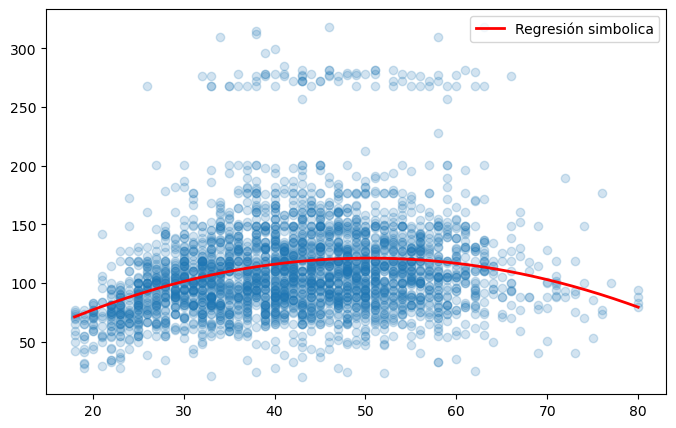

x0*(4.8084645 + x0*(-0.047698777))

In [22]:
X_grid = np.linspace(X.min(),X.max(),500)
X_grid = X_grid.reshape(-1,1)

y_pred = model.predict(X_grid)
plt.figure(figsize = (8,5))
plt.scatter(X, y, alpha = 0.2)
plt.plot(X_grid,y_pred, linewidth = 2, color = 'red',label = "Regresión simbolica")
plt.legend()
plt.show()

model.sympy()

/home/gdiek/anaconda3/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/gdiek/anaconda3/lib/python3.13/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.500e+04
Progress: 58 / 620 total iterations (9.355%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.741e+03  0.000e+00  y = 111.7
3           1.685e+03  1.605e-02  y = x₀ + 69.289
7           1.674e+03  1.668e-03  y = x₀ - ((x₀ * 0.29271) + -81.704)
13          1.674e+03  5.424e-06  y = ((((x₀ + 43.124) - (0.95434 ^ x₀)) * 0.69996) - -25.74...
                                      1) + 25.961
14          1.617e+03  3.411e-02  y = (((x₀ + x₀) - 4.2651) * (1.9262 - log(x₀ * 0.043836)))...
                                       + 9.9077
19          1.601e+03  1.976e-03  y = ((x₀ - ((x₀ - 8.5347) * -2.2376)) * ((((x₀ * 0.048986)...
                                       - 1.9199) * -0.39084) + 1.0255)) + 4.9563
───────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


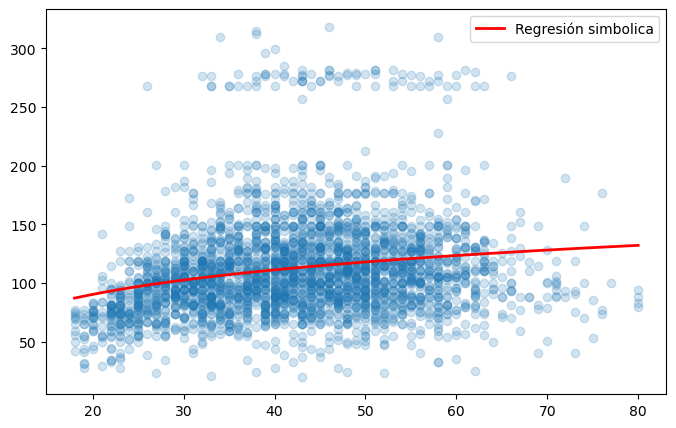

30.145214*log(x0)

  - outputs/20260921_123849_F7aDWY/hall_of_fame.csv


In [25]:
from ISLP  import load_data
import pandas as pd

#PREPARACION DE DATOS

Wage = load_data("Wage")
X = Wage["age"].to_numpy()
y = Wage["wage"].to_numpy()


## REGRESIÓN
model = PySRRegressor(
    niterations=20,
    binary_operators=[
        "+",
        "-",
        "*",
        "^"
    ],
    unary_operators = ["sin","exp","log"],
    verbosity=1
)

X_grid = X.reshape(-1,1)

model.fit(X_grid, y)

X_grid = np.linspace(X.min(),X.max(),500)
X_grid = X_grid.reshape(-1,1)

y_pred = model.predict(X_grid)
plt.figure(figsize = (8,5))
plt.scatter(X, y, alpha = 0.2)
plt.plot(X_grid,y_pred, linewidth = 2, color = 'red',label = "Regresión simbolica")
plt.legend()
plt.show()

model.sympy()

In [26]:
model

PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                          111.70467   
	1        0.016116                                     x0 - -69.28585   
	2  >>>>  0.021579                                log(x0) * 30.145214   
	3        0.001411                   log(x0 + -6.3237596) * 31.618069   
	4        0.003138     (-1.4860965 - log(x0 - 14.658346)) * -23.47187   
	5        0.012708  ((22.62315 - (log(x0) * 4.627302)) * x0) + -10...   
	6        0.000095  ((20.214182 - (log(x0) * 4.2109566)) * (x0 + -...   
	7        0.000261  (x0 + -220.15515) + ((((x0 * -3.8432386) - (lo...   
	
	        loss  complexity  
	0  1740.6948           1  
	1  1685.4839           3  
	2  1649.5028           4  
	3  1644.8552           6  
	4  1634.5643           8  
	5  1593.5424          10  
	6  1593.2390          12  
	7  1591.5735          16  
]